# Previsão — Copa do Mundo 2026
## Modelo Final: Regressão Linear v6

**Modelo selecionado:** Regressão Linear com features v6 (11 features, 216 amostras)

**Justificativa da escolha:**
- Melhor MAE no teste da Copa 2022 (0.446 — menor de todos os modelos e versões)
- Mais interpretável — coeficientes lineares explicam diretamente o impacto de cada feature
- O ensemble (LR + RF + XGBoost) penalizava incorretamente times que jogam consistentemente contra adversários fortes no ciclo (ex: França com ELO adversário 1264 — o maior do dataset)
- RF e XGBoost aprenderam erroneamente que ELO alto de adversários → menos gols na Copa, o que não se confirma para grandes seleções

**Features v6:**
- 7 features originais (ciclo + últimos 15 jogos)
- `elo_medio_adv_ciclo` e `elo_medio_adv_ult15`
- `media_gols_ultimas2_copas` — histórico ofensivo nas Copas anteriores
- `fase_ultima_copa` — fase atingida na Copa imediatamente anterior

**Erro esperado:** ~0.45 gols por jogo

## 1. Imports e Carregamento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import sys
sys.path.append('../src/features')
from elo import calcular_elo_historico

from sklearn.linear_model import LinearRegression

sns.set_theme(style='whitegrid')
np.random.seed(42)

df_features = pd.read_csv('../data/processed/features_completo_v6.csv')
df_raw      = pd.read_csv('../data/raw/results.csv', parse_dates=['date'])

df_mercado_raw = pd.read_excel('../data/raw/football_team_values_2010_2026.xlsx',
                                sheet_name='Football Values')
df_mercado_raw.columns = ['copa', 'selecao', 'valor_mercado']
df_mercado_2026 = df_mercado_raw[df_mercado_raw['copa'] == 2026].copy()

print(f'Dataset treino (v6): {df_features.shape}')
print(f'Seleções com valor de mercado 2026: {len(df_mercado_2026)}')

Dataset treino (v6): (248, 14)
Seleções com valor de mercado 2026: 50


## 2. ELO Histórico e Retreino

Treinamos com todos os dados disponíveis (248 amostras, 1994–2022).

In [2]:
df = calcular_elo_historico(df_raw, elo_inicial=1000, k_competitivo=40, k_amistoso=20)
print(f'ELO calculado para {len(df)} jogos')

features = [
    'media_gols_marcados_ciclo', 'media_gols_sofridos_ciclo',
    'pct_vitorias_ciclo', 'total_jogos_ciclo',
    'media_gols_marcados_ult15', 'media_gols_sofridos_ult15',
    'pct_vitorias_ult15', 'elo_medio_adv_ciclo', 'elo_medio_adv_ult15',
    'media_gols_ultimas2_copas', 'fase_ultima_copa'
]

X_full = df_features[features]
y_full = df_features['media_gols_copa']

lr = LinearRegression().fit(X_full, y_full)

print(f'Regressão Linear treinada com {len(X_full)} amostras')
print(f'\nCoeficientes do modelo:')
for feat, coef in sorted(zip(features, lr.coef_), key=lambda x: abs(x[1]), reverse=True):
    print(f'  {feat:<35} {coef:+.4f}')
print(f'  Intercepto: {lr.intercept_:.4f}')

ELO calculado para 49287 jogos
Regressão Linear treinada com 248 amostras

Coeficientes do modelo:
  pct_vitorias_ult15                  -0.9139
  pct_vitorias_ciclo                  +0.4436
  media_gols_marcados_ult15           +0.3996
  media_gols_sofridos_ciclo           -0.3614
  media_gols_ultimas2_copas           +0.1461
  media_gols_sofridos_ult15           -0.0856
  media_gols_marcados_ciclo           +0.0529
  total_jogos_ciclo                   -0.0089
  fase_ultima_copa                    -0.0036
  elo_medio_adv_ciclo                 +0.0020
  elo_medio_adv_ult15                 +0.0000
  Intercepto: -1.0137


## 3. Datas das Copas e Funções Auxiliares

In [3]:
copas_datas = {
    1990: ('1990-06-08', '1990-07-08'),
    1994: ('1994-06-17', '1994-07-17'),
    1998: ('1998-06-10', '1998-07-12'),
    2002: ('2002-05-31', '2002-06-30'),
    2006: ('2006-06-09', '2006-07-09'),
    2010: ('2010-06-11', '2010-07-11'),
    2014: ('2014-06-12', '2014-07-13'),
    2018: ('2018-06-14', '2018-07-15'),
    2022: ('2022-11-20', '2022-12-18'),
}

def get_fase(df_copa, selecao):
    jogos = df_copa[
        (df_copa['home_team'] == selecao) |
        (df_copa['away_team'] == selecao)
    ]
    if len(jogos) == 0: return 0
    n = len(jogos)
    if n == 3:   return 1
    elif n == 4: return 2
    elif n == 5: return 3
    elif n == 6: return 4
    elif n == 7:
        ultimo = jogos.sort_values('date').iloc[-1]
        ganhou = (ultimo['home_score'] > ultimo['away_score']) if ultimo['home_team'] == selecao                  else (ultimo['away_score'] > ultimo['home_score'])
        return 6 if ganhou else 5
    return min(n - 2, 6)

def get_media_gols_copa(df_copa, selecao):
    jogos = df_copa[
        (df_copa['home_team'] == selecao) |
        (df_copa['away_team'] == selecao)
    ]
    if len(jogos) == 0: return np.nan
    return np.mean([
        row['home_score'] if row['home_team'] == selecao else row['away_score']
        for _, row in jogos.iterrows()
    ])

print('Funções definidas!')

Funções definidas!


## 4. Ciclo 2026 e Função de Features v6

In [4]:
ciclo_2026 = df[
    (df['date'] >= '2022-12-20') &
    (df['date'] <= '2026-06-10') &
    (df['tournament'] != 'FIFA World Cup')
]
print(f'Jogos no ciclo 2026: {len(ciclo_2026)}')

def calcular_features_2026_v6(selecao, ciclo, min_jogos=10):
    jogos = ciclo[
        (ciclo['home_team'] == selecao) |
        (ciclo['away_team'] == selecao)
    ].sort_values('date')

    if len(jogos) < min_jogos:
        raise ValueError(f'Apenas {len(jogos)} jogos')

    gm, gs, vit, elo_adv = [], [], [], []
    for _, row in jogos.iterrows():
        if row['home_team'] == selecao:
            gm.append(row['home_score']); gs.append(row['away_score'])
            vit.append(1 if row['home_score'] > row['away_score'] else 0)
            elo_adv.append(row['elo_away_antes'])
        else:
            gm.append(row['away_score']); gs.append(row['home_score'])
            vit.append(1 if row['away_score'] > row['home_score'] else 0)
            elo_adv.append(row['elo_home_antes'])

    gm, gs, vit = np.array(gm), np.array(gs), np.array(vit)
    elo_adv = np.array(elo_adv)

    ult15 = jogos.tail(15)
    gm15, gs15, vit15, ea15 = [], [], [], []
    for _, row in ult15.iterrows():
        if row['home_team'] == selecao:
            gm15.append(row['home_score']); gs15.append(row['away_score'])
            vit15.append(1 if row['home_score'] > row['away_score'] else 0)
            ea15.append(row['elo_away_antes'])
        else:
            gm15.append(row['away_score']); gs15.append(row['home_score'])
            vit15.append(1 if row['away_score'] > row['home_score'] else 0)
            ea15.append(row['elo_home_antes'])

    # Histórico Copa 2022 e 2018
    inicio_22, fim_22 = copas_datas[2022]
    copa_22 = df[
        (df['tournament'] == 'FIFA World Cup') &
        (df['date'] >= inicio_22) & (df['date'] <= fim_22)
    ]
    inicio_18, fim_18 = copas_datas[2018]
    copa_18 = df[
        (df['tournament'] == 'FIFA World Cup') &
        (df['date'] >= inicio_18) & (df['date'] <= fim_18)
    ]

    fase_22 = get_fase(copa_22, selecao)
    mg_22   = get_media_gols_copa(copa_22, selecao)
    mg_18   = get_media_gols_copa(copa_18, selecao)

    gols_hist = [g for g in [mg_22, mg_18] if not np.isnan(g)]
    media_hist = np.mean(gols_hist) if gols_hist else 0.0

    return {
        'media_gols_marcados_ciclo': gm.mean(),
        'media_gols_sofridos_ciclo': gs.mean(),
        'pct_vitorias_ciclo':        vit.mean(),
        'total_jogos_ciclo':         len(jogos),
        'media_gols_marcados_ult15': np.array(gm15).mean(),
        'media_gols_sofridos_ult15': np.array(gs15).mean(),
        'pct_vitorias_ult15':        np.array(vit15).mean(),
        'elo_medio_adv_ciclo':       elo_adv.mean(),
        'elo_medio_adv_ult15':       np.array(ea15).mean(),
        'media_gols_ultimas2_copas': media_hist,
        'fase_ultima_copa':          fase_22,
    }

print('Função definida!')

Jogos no ciclo 2026: 3465
Função definida!


## 5. Seleções Classificadas

In [5]:
selecoes_2026 = {
    'Argentina': 'CONMEBOL', 'Brazil': 'CONMEBOL', 'Colombia': 'CONMEBOL',
    'Ecuador': 'CONMEBOL', 'Paraguay': 'CONMEBOL', 'Uruguay': 'CONMEBOL',
    'England': 'UEFA', 'France': 'UEFA', 'Croatia': 'UEFA', 'Norway': 'UEFA',
    'Portugal': 'UEFA', 'Germany': 'UEFA', 'Netherlands': 'UEFA',
    'Austria': 'UEFA', 'Belgium': 'UEFA', 'Scotland': 'UEFA',
    'Spain': 'UEFA', 'Switzerland': 'UEFA', 'Sweden': 'UEFA',
    'Turkey': 'UEFA', 'Bosnia and Herzegovina': 'UEFA', 'Czech Republic': 'UEFA',
    'United States': 'CONCACAF', 'Canada': 'CONCACAF', 'Mexico': 'CONCACAF',
    'Panama': 'CONCACAF', 'Haiti': 'CONCACAF', 'Curaçao': 'CONCACAF',
    'Morocco': 'CAF', 'Senegal': 'CAF', 'Egypt': 'CAF', 'Ghana': 'CAF',
    'South Africa': 'CAF', 'Ivory Coast': 'CAF', 'Algeria': 'CAF',
    'Tunisia': 'CAF', 'Cape Verde': 'CAF', 'DR Congo': 'CAF',
    'Japan': 'AFC', 'South Korea': 'AFC', 'Iran': 'AFC', 'Australia': 'AFC',
    'Saudi Arabia': 'AFC', 'Iraq': 'AFC', 'Jordan': 'AFC',
    'Uzbekistan': 'AFC', 'Qatar': 'AFC',
    'New Zealand': 'OFC',
}
print(f'Total: {len(selecoes_2026)} seleções')

Total: 48 seleções


## 6. Calculando Features e Previsões

In [6]:
nome_mercado_map = {
    'DR Congo': 'Democratic Republic of the Congo',
    'Turkey':   'Turkiye',
}

dados_2026 = []
sem_dados  = []

for selecao, conf in selecoes_2026.items():
    try:
        feat = calcular_features_2026_v6(selecao, ciclo_2026, min_jogos=10)
        feat['selecao']      = selecao
        feat['confederacao'] = conf

        nome_busca = nome_mercado_map.get(selecao, selecao)
        row_m = df_mercado_2026[
            df_mercado_2026['selecao'].str.lower() == nome_busca.lower()
        ]
        feat['valor_mercado_milhoes'] = float(row_m['valor_mercado'].values[0])             if len(row_m) > 0 else np.nan

        dados_2026.append(feat)
    except Exception as e:
        sem_dados.append(selecao)
        print(f'Sem dados: {selecao} — {e}')

df_2026 = pd.DataFrame(dados_2026)

# Previsão — apenas Regressão Linear v6
X_2026 = df_2026[features]
df_2026['previsao'] = lr.predict(X_2026)

df_2026 = df_2026.sort_values('previsao', ascending=False).reset_index(drop=True)

print(f'Previsões: {len(df_2026)} seleções')
print(f'\nTop 20:')
print(df_2026[['selecao','confederacao','fase_ultima_copa',
               'media_gols_ultimas2_copas','previsao','valor_mercado_milhoes']]
      .head(20).to_string(index=False))

Previsões: 48 seleções

Top 20:
    selecao confederacao  fase_ultima_copa  media_gols_ultimas2_copas  previsao  valor_mercado_milhoes
      Spain         UEFA                 2                   2.000000  2.181636                1150.00
  Argentina     CONMEBOL                 5                   1.821429  1.999126                 575.00
   Colombia     CONMEBOL                 0                   1.500000  1.936990                 285.10
Netherlands         UEFA                 3                   2.000000  1.930983                 808.00
   Portugal         UEFA                 3                   1.950000  1.924181                 841.00
    Belgium         UEFA                 1                   1.309524  1.863679                 442.20
    England         UEFA                 3                   2.157143  1.844700                1300.00
     France         UEFA                 5                   2.142857  1.798974                1290.00
     Norway         UEFA                 

## 7. Visualização — Top 20

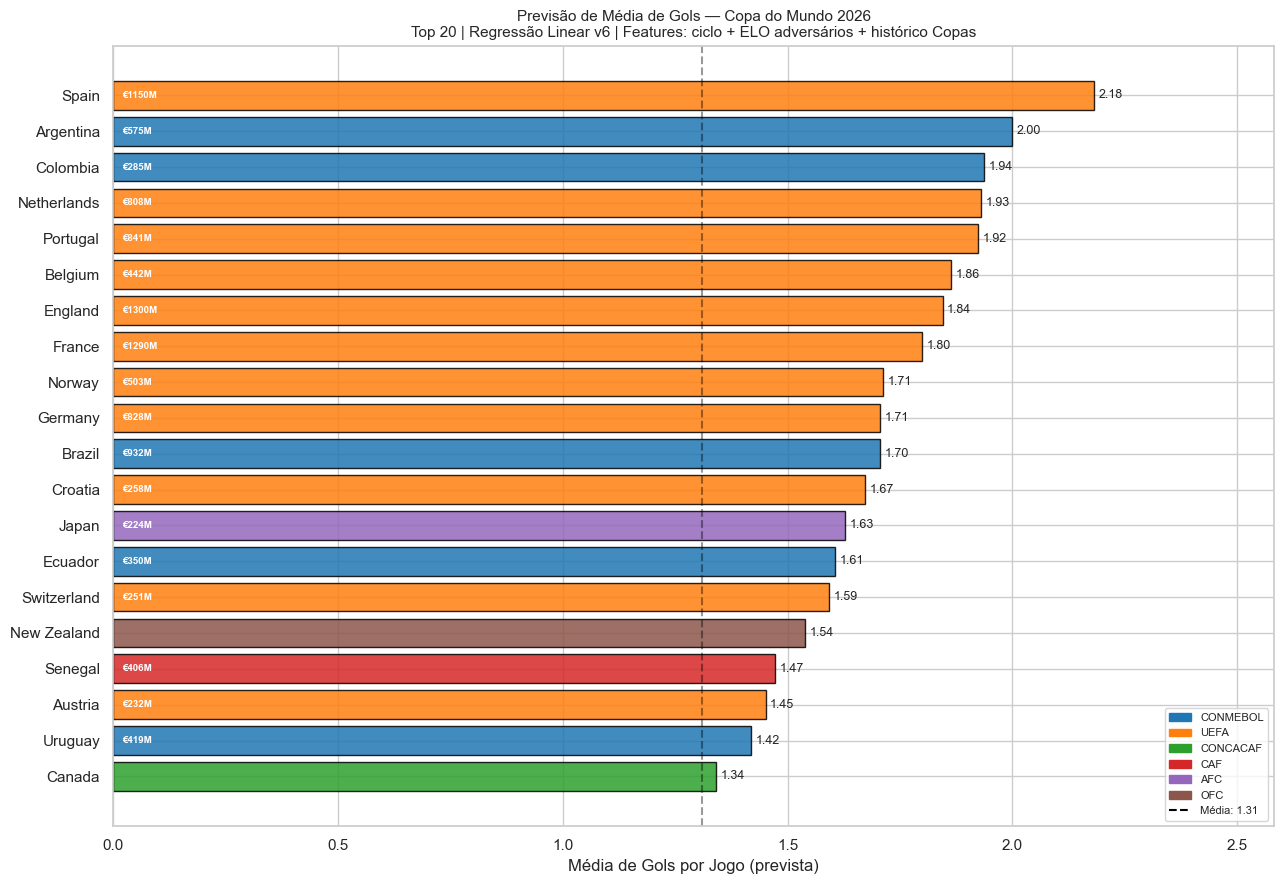

In [7]:
cores_conf = {
    'CONMEBOL': '#1f77b4', 'UEFA': '#ff7f0e', 'CONCACAF': '#2ca02c',
    'CAF': '#d62728', 'AFC': '#9467bd', 'OFC': '#8c564b'
}

top20 = df_2026.head(20)
fig, ax = plt.subplots(figsize=(13, 9))

cores_barras = [cores_conf[c] for c in top20['confederacao'][::-1]]
bars = ax.barh(top20['selecao'][::-1], top20['previsao'][::-1],
               color=cores_barras, edgecolor='black', alpha=0.85)

for bar, val in zip(bars, top20['previsao'][::-1]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)

for i, (_, row) in enumerate(top20[::-1].iterrows()):
    if not pd.isna(row['valor_mercado_milhoes']):
        ax.text(0.02, i, f'€{row["valor_mercado_milhoes"]:.0f}M',
                va='center', fontsize=7, color='white', fontweight='bold')

media_geral = df_2026['previsao'].mean()
ax.axvline(media_geral, color='black', linestyle='--', alpha=0.4)

legend_conf = [mpatches.Patch(color=c, label=conf) for conf, c in cores_conf.items()]
legend_conf.append(plt.Line2D([0],[0], color='black', linestyle='--',
                               label=f'Média: {media_geral:.2f}'))
ax.legend(handles=legend_conf, loc='lower right', fontsize=8)
ax.set_xlabel('Média de Gols por Jogo (prevista)')
ax.set_title(
    'Previsão de Média de Gols — Copa do Mundo 2026\n'
    'Top 20 | Regressão Linear v6 | Features: ciclo + ELO adversários + histórico Copas',
    fontsize=11
)
ax.set_xlim(0, top20['previsao'].max() + 0.4)
plt.tight_layout()
plt.savefig('../article/figures/previsao_2026_top20_final.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Correlação: Previsão vs Valor de Mercado

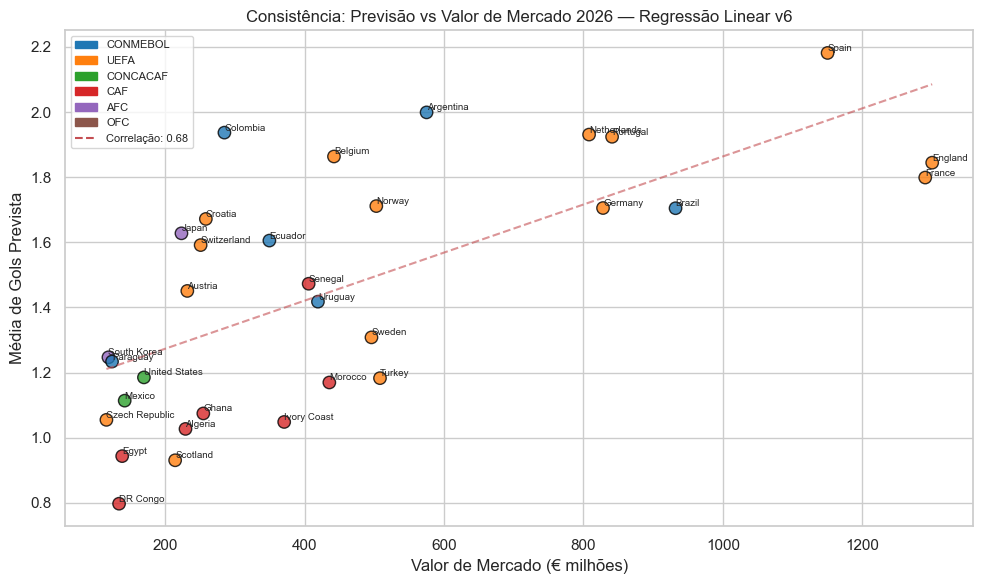

Correlação Pearson: 0.6789


In [8]:
df_com_m = df_2026.dropna(subset=['valor_mercado_milhoes'])
corr = df_com_m['valor_mercado_milhoes'].corr(df_com_m['previsao'])

fig, ax = plt.subplots(figsize=(10, 6))
cores = [cores_conf[c] for c in df_com_m['confederacao']]
ax.scatter(df_com_m['valor_mercado_milhoes'], df_com_m['previsao'],
           c=cores, s=80, edgecolors='black', alpha=0.8)

for _, row in df_com_m.iterrows():
    ax.annotate(row['selecao'],
                (row['valor_mercado_milhoes'], row['previsao']),
                fontsize=7, ha='left', va='bottom')

z = np.polyfit(df_com_m['valor_mercado_milhoes'], df_com_m['previsao'], 1)
x_l = np.linspace(df_com_m['valor_mercado_milhoes'].min(),
                  df_com_m['valor_mercado_milhoes'].max(), 100)
ax.plot(x_l, np.poly1d(z)(x_l), 'r--', alpha=0.6, label=f'Correlação: {corr:.2f}')

legend_conf = [mpatches.Patch(color=c, label=conf) for conf, c in cores_conf.items()]
legend_conf.append(plt.Line2D([0],[0], color='r', linestyle='--',
                               label=f'Correlação: {corr:.2f}'))
ax.legend(handles=legend_conf, fontsize=8)
ax.set_xlabel('Valor de Mercado (€ milhões)')
ax.set_ylabel('Média de Gols Prevista')
ax.set_title('Consistência: Previsão vs Valor de Mercado 2026 — Regressão Linear v6')
plt.tight_layout()
plt.savefig('../article/figures/previsao_vs_mercado_2026.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Correlação Pearson: {corr:.4f}')

## 9. Visualização por Confederação

C:\Users\joaog\AppData\Local\Temp\ipykernel_21580\261039165.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_2026, x='confederacao', y='previsao',


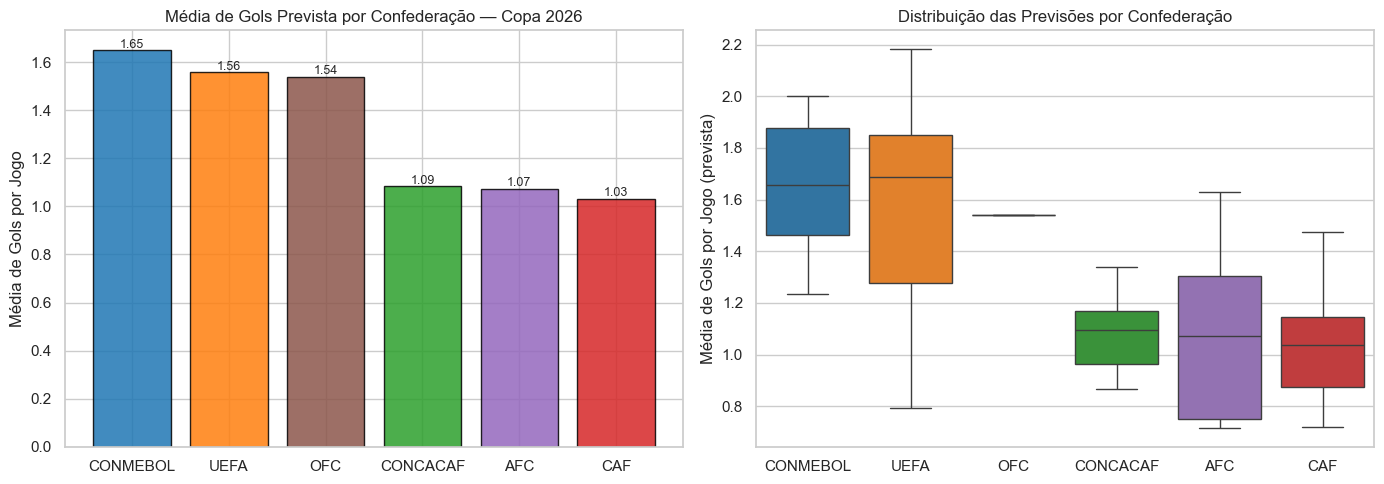

Média por confederação:
confederacao
CONMEBOL    1.650
UEFA        1.559
OFC         1.539
CONCACAF    1.085
AFC         1.073
CAF         1.032


In [9]:
media_conf = df_2026.groupby('confederacao')['previsao'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cores = [cores_conf[c] for c in media_conf.index]
axes[0].bar(media_conf.index, media_conf.values, color=cores, edgecolor='black', alpha=0.85)
for i, (conf, val) in enumerate(media_conf.items()):
    axes[0].text(i, val + 0.01, f'{val:.2f}', ha='center', fontsize=9)
axes[0].set_title('Média de Gols Prevista por Confederação — Copa 2026')
axes[0].set_ylabel('Média de Gols por Jogo')

sns.boxplot(data=df_2026, x='confederacao', y='previsao',
            order=media_conf.index.tolist(), palette=cores_conf,
            ax=axes[1], legend=False)
axes[1].set_title('Distribuição das Previsões por Confederação')
axes[1].set_ylabel('Média de Gols por Jogo (prevista)')
axes[1].set_xlabel('')
plt.tight_layout()
plt.savefig('../article/figures/previsao_2026_confederacoes_final.png', dpi=150, bbox_inches='tight')
plt.show()

print('Média por confederação:')
print(media_conf.round(3).to_string())

## 10. Coeficientes do Modelo — Interpretação

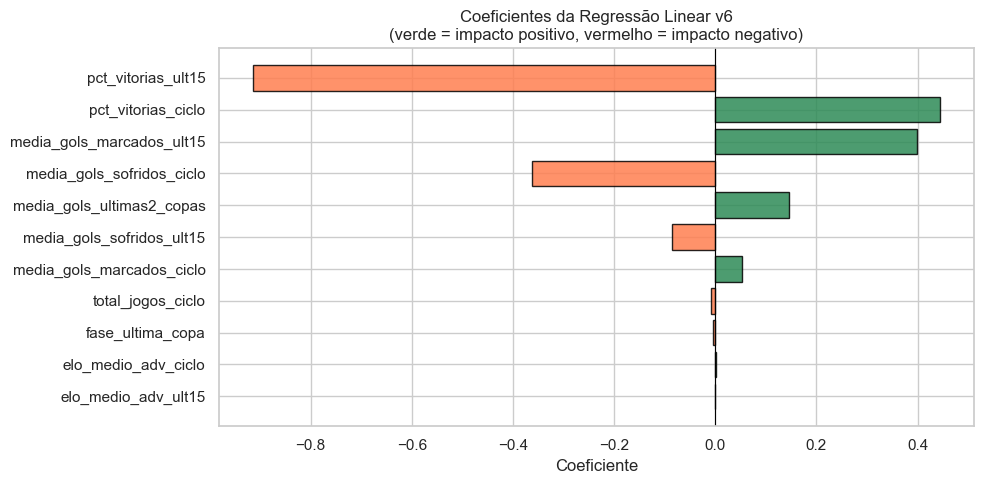

In [10]:
coef_df = pd.DataFrame({
    'Feature': features,
    'Coeficiente': lr.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['seagreen' if c > 0 else 'coral' for c in coef_df['Coeficiente']]
ax.barh(coef_df['Feature'][::-1], coef_df['Coeficiente'][::-1],
        color=colors[::-1], edgecolor='black', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente')
ax.set_title('Coeficientes da Regressão Linear v6\n(verde = impacto positivo, vermelho = impacto negativo)')
plt.tight_layout()
plt.savefig('../article/figures/coeficientes_lr_v6.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Salvamento

In [11]:
cols = [
    'selecao', 'confederacao', 'total_jogos_ciclo',
    'media_gols_marcados_ciclo', 'media_gols_marcados_ult15',
    'elo_medio_adv_ciclo', 'fase_ultima_copa',
    'media_gols_ultimas2_copas', 'valor_mercado_milhoes', 'previsao'
]

df_2026[cols].to_csv('../data/processed/previsao_2026_final.csv', index=False)
df_2026[cols].to_csv('../article/tables/previsao_2026_final.csv', index=False)
print('Salvo!')
print(f'\nResumo das previsões:')
print(df_2026['previsao'].describe().round(3))

Salvo!

Resumo das previsões:
count    48.000
mean      1.310
std       0.402
min       0.717
25%       1.006
50%       1.241
75%       1.639
max       2.182
Name: previsao, dtype: float64


## 12. Conclusões

**Modelo final:** Regressão Linear v6 — melhor MAE no teste (0.446), mais interpretável e sem os vieses do ensemble.

**Por que não usar o ensemble:**
RF e XGBoost aprenderam que ELO alto dos adversários correlaciona negativamente com gols na Copa — um viés espúrio que penaliza grandes seleções como a França (ELO adversário 1264, o maior do dataset).

**Evolução do projeto:**
- v1 baseline (0.4295 MAE CV) → v4 + ELO adversários → **v6 + histórico Copas (0.4465 MAE CV, 0.446 MAE teste)**

**Limitações:** ciclo disponível até março/2026, lesões e contexto tático não capturados, erro esperado ~0.45 gols/jogo.

In [12]:
selecoes_principais = [
    'Spain', 'Argentina', 'Colombia', 'Netherlands', 'Portugal',
    'Belgium', 'England', 'France', 'Germany', 'Brazil',
    'Croatia', 'Norway', 'Japan'
]

print(f'{"Seleção":<20} {"Ciclo Gols":>10} {"Ult15 Gols":>10} {"ELO Adv":>8} {"Fase 2022":>10} {"Hist 2 Copas":>13} {"Previsão":>9}')
print('-' * 85)
for sel in selecoes_principais:
    row = df_2026[df_2026['selecao'] == sel].iloc[0]
    print(f'{sel:<20} {row["media_gols_marcados_ciclo"]:>10.2f} {row["media_gols_marcados_ult15"]:>10.2f} '
          f'{row["elo_medio_adv_ciclo"]:>8.0f} {row["fase_ultima_copa"]:>10.0f} '
          f'{row["media_gols_ultimas2_copas"]:>13.2f} {row["previsao"]:>9.2f}')

Seleção              Ciclo Gols Ult15 Gols  ELO Adv  Fase 2022  Hist 2 Copas  Previsão
-------------------------------------------------------------------------------------
Spain                      2.67       2.93     1269          2          2.00      2.18
Argentina                  2.16       2.33     1232          5          1.82      2.00
Colombia                   1.82       2.00     1328          0          1.50      1.94
Netherlands                2.42       2.67     1223          3          2.00      1.93
Portugal                   2.58       2.47     1188          3          1.95      1.92
Belgium                    2.22       2.67     1185          1          1.31      1.86
England                    2.10       2.53     1197          3          2.16      1.84
France                     2.24       2.27     1264          5          2.14      1.80
Germany                    2.11       2.47     1300          1          1.33      1.71
Brazil                     1.66       1.80  